In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore


In [2]:
np.random.seed(0)
data = {
    'Student_ID': range(1, 101),
    'Math': np.random.randint(50, 100, 100).astype(object),
    'Physics': np.random.randint(40, 95, 100).astype(float),
    'English': np.random.randint(30, 90, 100).astype(object),
    'Attendance': np.random.uniform(0.7, 1, 100),
    'GPA': np.random.uniform(2.5, 4, 100)
}



In [3]:
data['Math'][10] = np.nan
data['Physics'][20] = 200        
data['English'][30] = 'A'        


In [4]:
df = pd.DataFrame(data)
print("Original Academic Performance Dataset:")
display(df.head(25))


Original Academic Performance Dataset:


,Student_ID,Math,Physics,English,Attendance,GPA
0,1,94,45.0,63,0.983236,3.573342
1,2,97,81.0,70,0.882476,3.229239
2,3,50,75.0,62,0.878997,3.562822
3,4,53,40.0,66,0.935093,3.247210
4,5,53,71.0,89,0.850008,3.766825
5,6,89,45.0,89,0.715111,2.791513
6,7,59,70.0,87,0.909729,3.659989
7,8,69,40.0,36,0.997719,3.961388
8,9,71,89.0,51,0.780179,3.793465
9,10,86,90.0,61,0.903727,3.670640


In [5]:
print("Missing Values Before Cleaning:")
display(df.isnull().sum())


Missing Values Before Cleaning:


Student_ID    0
Math          1
Physics       0
English       0
Attendance    0
GPA           0
dtype: int64

In [6]:
inconsistent_english = pd.to_numeric(df['English'], errors='coerce').isnull().sum()
print("Inconsistencies in English column:", inconsistent_english)


Inconsistencies in English column: 1


In [7]:
df['English'] = pd.to_numeric(df['English'], errors='coerce')
print("Dataset After Converting English to Numeric:")
display(df.head())


Dataset After Converting English to Numeric:


,Student_ID,Math,Physics,English,Attendance,GPA
0,1,94,45.0,63.0,0.983236,3.573342
1,2,97,81.0,70.0,0.882476,3.229239
2,3,50,75.0,62.0,0.878997,3.562822
3,4,53,40.0,66.0,0.935093,3.247210
4,5,53,71.0,89.0,0.850008,3.766825


In [8]:
df['Math'] = df['Math'].fillna(df['Math'].mean())

In [9]:
df['English'] = df['English'].fillna(df['English'].mean())
print("Missing Values After Handling:")
display(df.isnull().sum())
print("Dataset After Handling Missing Values and Inconsistencies:")
display(df.head())


Missing Values After Handling:


Student_ID    0
Math          0
Physics       0
English       0
Attendance    0
GPA           0
dtype: int64

Dataset After Handling Missing Values and Inconsistencies:


,Student_ID,Math,Physics,English,Attendance,GPA
0,1,94,45.0,63.0,0.983236,3.573342
1,2,97,81.0,70.0,0.882476,3.229239
2,3,50,75.0,62.0,0.878997,3.562822
3,4,53,40.0,66.0,0.935093,3.247210
4,5,53,71.0,89.0,0.850008,3.766825


In [10]:

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Numeric Columns:")
print(numeric_cols)




Numeric Columns:
['Student_ID', 'Physics', 'English', 'Attendance', 'GPA']


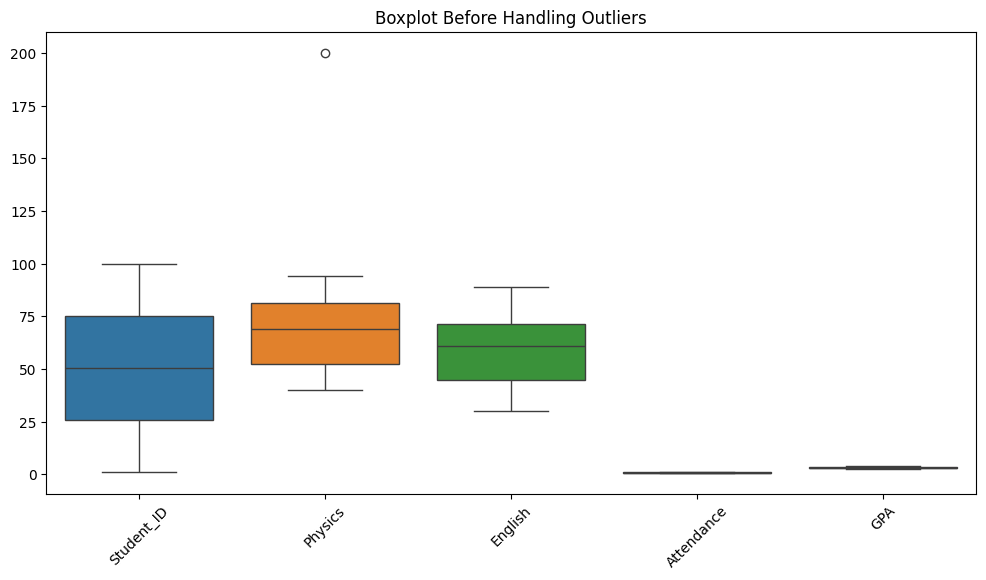

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot Before Handling Outliers")
plt.xticks(rotation=45)
plt.show()


In [12]:
z_scores = np.abs(zscore(df[numeric_cols]))
threshold = 3
outlier_indices = np.where(z_scores > threshold)[0]
print("Outlier Row Indices:")
print(outlier_indices)
print("Outlier Rows:")
display(df.iloc[outlier_indices])


Outlier Row Indices:
[20]
Outlier Rows:


,Student_ID,Math,Physics,English,Attendance,GPA
20,21,74,200.0,41.0,0.904163,3.109181


In [13]:


physics_mean = df[df['Physics'] <= 100]['Physics'].mean()

df.loc[df['Physics'] > 100, 'Physics'] = physics_mean

print("Physics mean value:", physics_mean)

print("Dataset After Handling Outliers:")
display(df.head(25))



Physics mean value: 66.35353535353535
Dataset After Handling Outliers:


,Student_ID,Math,Physics,English,Attendance,GPA
0,1,94,45.000000,63.0,0.983236,3.573342
1,2,97,81.000000,70.0,0.882476,3.229239
2,3,50,75.000000,62.0,0.878997,3.562822
3,4,53,40.000000,66.0,0.935093,3.247210
4,5,53,71.000000,89.0,0.850008,3.766825
5,6,89,45.000000,89.0,0.715111,2.791513
6,7,59,70.000000,87.0,0.909729,3.659989
7,8,69,40.000000,36.0,0.997719,3.961388
8,9,71,89.000000,51.0,0.780179,3.793465
9,10,86,90.000000,61.0,0.903727,3.670640


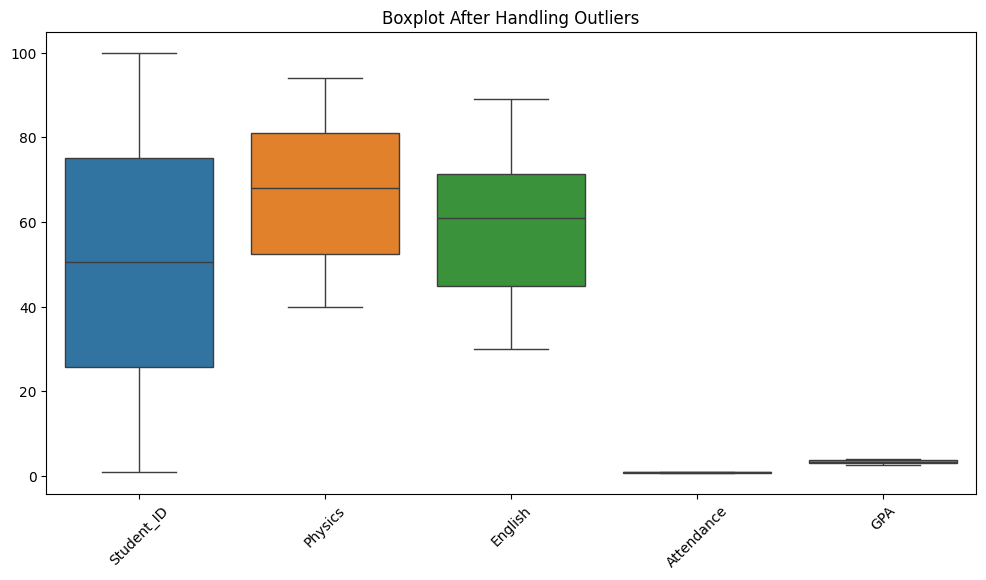

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot After Handling Outliers")
plt.xticks(rotation=45)
plt.show()


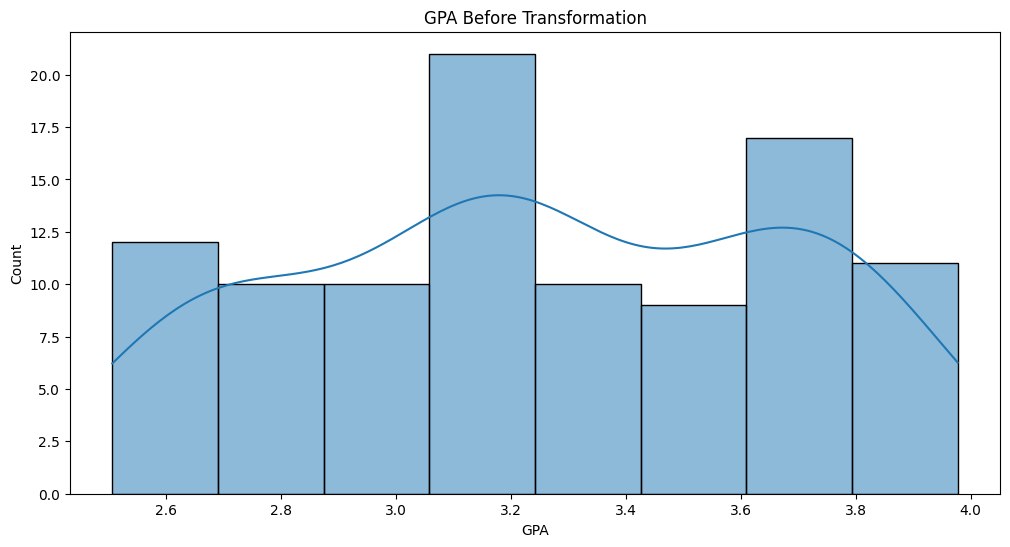

In [15]:
plt.figure(figsize=(12, 6))
sns.histplot(df['GPA'], kde=True)
plt.title("GPA Before Transformation")
plt.show()



In [16]:
df['GPA_Log'] = np.log1p(df['GPA'])
print("Dataset After Applying Log Transformation on GPA:")
display(df.head())


Dataset After Applying Log Transformation on GPA:


,Student_ID,Math,Physics,English,Attendance,GPA,GPA_Log
0,1,94,45.0,63.0,0.983236,3.573342,1.520244
1,2,97,81.0,70.0,0.882476,3.229239,1.442022
2,3,50,75.0,62.0,0.878997,3.562822,1.517941
3,4,53,40.0,66.0,0.935093,3.247210,1.446262
4,5,53,71.0,89.0,0.850008,3.766825,1.561680


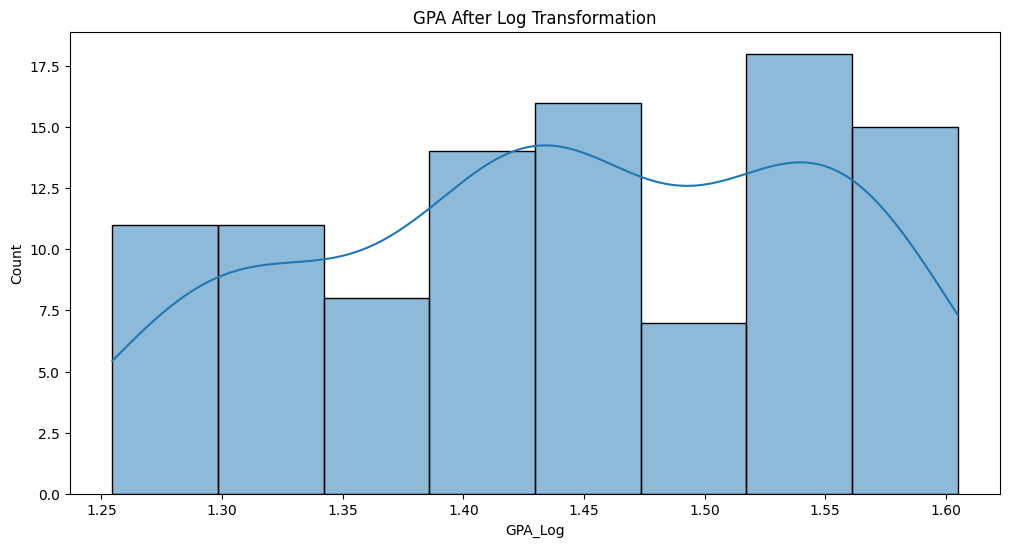

In [17]:
plt.figure(figsize=(12, 6))
sns.histplot(df['GPA_Log'], kde=True)
plt.title("GPA After Log Transformation")
plt.show()


In [18]:
print("Final Cleaned Dataset:")
display(df.head())


Final Cleaned Dataset:


,Student_ID,Math,Physics,English,Attendance,GPA,GPA_Log
0,1,94,45.0,63.0,0.983236,3.573342,1.520244
1,2,97,81.0,70.0,0.882476,3.229239,1.442022
2,3,50,75.0,62.0,0.878997,3.562822,1.517941
3,4,53,40.0,66.0,0.935093,3.247210,1.446262
4,5,53,71.0,89.0,0.850008,3.766825,1.561680


In [19]:
print("Final Missing Values:")
display(df.isnull().sum())


Final Missing Values:


Student_ID    0
Math          0
Physics       0
English       0
Attendance    0
GPA           0
GPA_Log       0
dtype: int64

In [20]:
print("Final Data Types:")
display(df.dtypes)
print("Final Shape of Dataset:")
print(df.shape)


Final Data Types:


Student_ID      int64
Math           object
Physics       float64
English       float64
Attendance    float64
GPA           float64
GPA_Log       float64
dtype: object

Final Shape of Dataset:
(100, 7)
